In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import seaborn.objects as so
from statsbombpy import sb

In [2]:
# Make Jupyter store Matplotlib outputs as SVG (vector)
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')       # or: set_matplotlib_formats('svg', 'pdf')

# Optional: keep text as real text (not paths) in SVGs
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'


In [3]:
cols = [
    'match_id', 'period', 'minute', 'second', 'timestamp', 'id', 'index', 'type', 'player', 'team', 'play_pattern', 'possession', 'possession_team',
    'under_pressure', 'tactics', 'duration', 'player_id', 'position', 'possession_team_id', 'team_id',
    'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_week',
    'dribble_outcome', 'duel_outcome', 'duel_type', 'location', 'pass_cross', 'pass_end_location', 
    'pass_height', 'pass_length', 'pass_outcome',  'pass_angle', 'pass_through_ball', 'pass_type', 
    'shot_outcome', 'shot_statsbomb_xg', 'shot_type'
]
performance_indicators = [
    'xg', 'shots',
    'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'pass_length',
    'crosses', 'dribbles', 
    'tackles', 'tackles_success', 'interceptions', 'pressures', 'blocks', 'fouls',
    'counterattacks'
]

## Functions

### Process match data

In [4]:
def add_match_info(df):

# sort events by match, period, and timestamp
    df = df.sort_values(['period', 'timestamp']).reset_index(drop=True)

# increment each time the scoreline changes
    df['scoreline_id'] = df['scoreline'].ne(df['scoreline'].shift()).cumsum()

### Create Next Goal column
    scoreline_by_group = df.groupby('scoreline_id')['scoreline'].first()
    scoreline_change = scoreline_by_group.shift(-1) - scoreline_by_group

# Create a DataFrame showing if the next scoreline is higher, lower, or the same
    scoreline_trend = pd.DataFrame({
        'current_scoreline': scoreline_by_group,
        'next_scoreline': scoreline_by_group.shift(-1),
        'next_goal': np.where(scoreline_change > 0, 'home',
                np.where(scoreline_change < 0, 'away', 'none'))
    })

    df = pd.merge(
        df,
        scoreline_trend.reset_index()[['scoreline_id', 'next_goal']],
        on='scoreline_id',
        how='left'
    )
    
### Create absolute timestamp in seconds
    secs_1st_half = pd.to_timedelta(
        df[df.period == 1]['timestamp']).dt.total_seconds().max()

    df['absolute_sec'] = np.where(
        df['period'] == 1,
        pd.to_timedelta(df['timestamp']).dt.total_seconds(),
        pd.to_timedelta(df['timestamp']).dt.total_seconds() + secs_1st_half
    )

    return df


### Define functions for aggregation on different levels

In [5]:
grouping_cols_scoreline = [
    'match_id', 'scoreline_id', 'home_score', 'away_score', 'scoreline', 'match_status', 'next_goal',
    'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_outcome', 'match_week'
    ]

def scoreline_agg(df):
    return pd.Series({
        'duration_s': df['absolute_sec'].max() - df['absolute_sec'].min(),
        'home_xg': df.loc[df['location'] == 'home', 'shot_statsbomb_xg'].sum(),
        'away_xg': df.loc[df['location'] == 'away', 'shot_statsbomb_xg'].sum(),
        'home_passes': ((df['type'] == 'Pass') & (df['location'] == 'home')).sum(),
        'away_passes': ((df['type'] == 'Pass') & (df['location'] == 'away')).sum(),
        'home_highpasses': ((df['pass_height'] == 'High Pass') & (df['location'] == 'home')).sum(),
        'away_highpasses': ((df['pass_height'] == 'High Pass') & (df['location'] == 'away')).sum(),
        'home_groundpasses': ((df['pass_height'] == 'Ground Pass') & (df['location'] == 'home')).sum(),
        'away_groundpasses': ((df['pass_height'] == 'Ground Pass') & (df['location'] == 'away')).sum(),
        'home_pressuredpasses': ((df['pressured_pass'] == True) & (df['location'] == 'home')).sum(),
        'away_pressuredpasses': ((df['pressured_pass'] == True) & (df['location'] == 'away')).sum(),
        'home_pressureddribbles': ((df['pressured_dribble'] == True) & (df['location'] == 'home')).sum(),
        'away_pressureddribbles': ((df['pressured_dribble'] == True) & (df['location'] == 'away')).sum(),
        'home_crosses': ((df['pass_cross'] == True) & (df['location'] == 'home')).sum(),
        'away_crosses': ((df['pass_cross'] == True) & (df['location'] == 'away')).sum(),
        'home_dribbles': ((df['type'] == 'Dribble') & (df['location'] == 'home')).sum(),
        'away_dribbles': ((df['type'] == 'Dribble') & (df['location'] == 'away')).sum(),
        'home_shots': ((df['type'] == 'Shot') & (df['location'] == 'home')).sum(),
        'away_shots': ((df['type'] == 'Shot') & (df['location'] == 'away')).sum(),
        'home_pass_length': df.loc[df['location'] == 'home', 'pass_length'].sum(),
        'away_pass_length': df.loc[df['location'] == 'away', 'pass_length'].sum(),
        'home_tackles': ((df['duel_type'] == 'Tackle') & (df['location'] == 'home')).sum(),
        'away_tackles': ((df['duel_type'] == 'Tackle') & (df['location'] == 'away')).sum(),
        'home_tackles_success': ((df['duel_type'] == 'Tackle') & (df['location'] == 'home') & (df['duel_outcome'].isin(['Won', 'Success', 'Success In Play', 'Success Out']))).sum(),
        'away_tackles_success': ((df['duel_type'] == 'Tackle') & (df['location'] == 'away') & (df['duel_outcome'].isin(['Won', 'Success', 'Success In Play', 'Success Out']))).sum(),
        'home_interceptions': ((df['type'] == 'Interception') & (df['location'] == 'home')).sum(),
        'away_interceptions': ((df['type'] == 'Interception') & (df['location'] == 'away')).sum(),
        'home_pressures': ((df['type'] == 'Pressure') & (df['location'] == 'home')).sum(),
        'away_pressures': ((df['type'] == 'Pressure') & (df['location'] == 'away')).sum(),
        'home_blocks': ((df['type'] == 'Block') & (df['location'] == 'home')).sum(),
        'away_blocks': ((df['type'] == 'Block') & (df['location'] == 'away')).sum(),
        'home_fouls': ((df['type'] == 'Foul Committed') & (df['location'] == 'home')).sum(),
        'away_fouls': ((df['type'] == 'Foul Committed') & (df['location'] == 'away')).sum(),
        'home_counterattacks': ((df['play_pattern'] == 'From Counter') & (df['location'] == 'home')).sum(),
        'away_counterattacks': ((df['play_pattern'] == 'From Counter') & (df['location'] == 'away')).sum(),
    })

grouping_cols_possession = [
    'match_id', 'possession', 'home_score', 'away_score', 'scoreline', 'match_status', 'possession_team', 'next_goal',
    'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_outcome', 'match_week'
]

def possession_agg(df):
    return pd.Series({
        'duration_s': df['absolute_sec'].max() - df['absolute_sec'].min(),
        'n_events' : df.shape[0],
        'home_goals' : df.loc[df['team'] == df['home_team'], 'home_goal'].sum(),
        'away_goals' : df.loc[df['team'] == df['away_team'], 'away_goal'].sum(),
        'home_xg': df.loc[df['team'] == df['home_team'], 'shot_statsbomb_xg'].sum(),
        'away_xg': df.loc[df['team'] == df['away_team'], 'shot_statsbomb_xg'].sum(),
        'home_passes': df.loc[df['team'] == df['home_team'], 'type'].eq('Pass').sum(),
        'away_passes': df.loc[df['team'] == df['away_team'], 'type'].eq('Pass').sum(),
        'home_highpasses': df.loc[df['team'] == df['home_team'], 'pass_height'].eq('High Pass').sum(),
        'away_highpasses': df.loc[df['team'] == df['away_team'], 'pass_height'].eq('High Pass').sum(),

        
        'att_goals' : df.loc[df['team_role'] == "attacking", 'Goal'].sum(),
        'att_xg' : df.loc[df['team_role'] == "attacking", 'shot_statsbomb_xg'].sum(),
        'att_shots' : df.loc[df['team_role'] == "attacking", 'type'].eq('Shot').sum(),
        'att_passes': df.loc[df['team_role'] == "attacking", 'type'].eq('Pass').sum(),
        'att_highpasses': df.loc[df['team_role'] == "attacking", 'pass_height'].eq('High Pass').sum(),
        'att_groundpasses': df.loc[df['team_role'] == "attacking", 'pass_height'].eq('Ground Pass').sum(),
        'att_crosses': df.loc[df['team_role'] == "attacking", 'pass_cross'].eq('True').sum(),
        'att_dribbles': df.loc[df['team_role'] == "attacking", 'type'].eq('Dribble').sum(),
        'att_shots': df.loc[df['team_role'] == "attacking", 'type'].eq('Shot').sum(),
        'att_pass_length': df.loc[df['team_role'] == "attacking", 'pass_length'].sum(),

        'def_tackles': ((df['duel_type'] == 'Tackle') & (df['team_role'] == 'defending')).sum(),
        'def_tackles_success': ((df['duel_type'] == 'Tackle') & (df['team_role'] == 'defending') & (df['duel_outcome'].isin(['Won', 'Success', 'Success In Play', 'Success Out']))).sum(),
        'def_interceptions': ((df['type'] == 'Interception') & (df['team_role'] == 'defending')).sum(),
        'def_pressures': ((df['type'] == 'Pressure') & (df['team_role'] == 'defending')).sum(),
        'def_blocks': ((df['type'] == 'Block') & (df['team_role'] == 'defending')).sum(),
        'def_fouls': ((df['type'] == 'Foul Committed') & (df['team_role'] == 'defending')).sum()
    })

def match_level_agg(df):
    df_matches_long = df.groupby('team').agg(
        match_id=('match_id', 'first'),
        location=('location', 'first'),
        match_outcome =('match_outcome', 'first'),
        goals=('Goal', 'sum'),
        xg=('shot_statsbomb_xg', 'sum'),
        shots = ('type', lambda x: (x == 'Shot').sum()),
        passes = ('type', lambda x: (x == 'Pass').sum()),
        pressuredpasses = ('pressured_pass', 'sum'),
        pressureddribbles = ('pressured_dribble', 'sum'),
        highpasses = ('pass_height', lambda x: (x == 'High Pass').sum()),
        groundpasses = ('pass_height', lambda x: (x == 'Ground Pass').sum()),
        pass_length = ('pass_length', 'sum'),
        crosses = ('pass_cross', lambda x: (x == True).sum()),
        dribbles = ('type', lambda x: (x == 'Dribble').sum()),
        tackles = ('duel_type', lambda x: (x == 'Tackle').sum()),
        tackles_success = ('duel_outcome', lambda x: x.isin(['Won', 'Success', 'Success In Play', 'Success Out']).sum()),
        interceptions = ('type', lambda x: (x == 'Interception').sum()),
        pressures = ('type', lambda x: (x == 'Pressure').sum()),
        blocks = ('type', lambda x: (x == 'Block').sum()),
        fouls = ('type', lambda x: (x == 'Foul Committed').sum()),
        counterattacks = ('play_pattern', lambda x: (x == 'From Counter').sum()),
    ).reset_index()

    m_id = df_matches_long['match_id'].unique()[0]
    match_outcome = df_matches_long['match_outcome'].unique()[0]

    ls_loc_dfs = []
    for loc in ['home', 'away']:
        df_temp = df_matches_long.loc[df_matches_long['location'] == loc].reset_index(drop=True).copy()
        df_temp = df_temp.drop(columns=['location', 'match_id', 'match_outcome'])
        df_temp = df_temp.add_prefix(f'{loc}_', axis=1)
        #df_temp[loc + '_team'] = df_temp['team']
        ls_loc_dfs.append(df_temp)

    df_matches_wide = pd.concat(ls_loc_dfs, axis=1)
    df_matches_wide.insert(0, 'match_id', m_id)
    df_matches_wide.insert(1, 'match_outcome', match_outcome)

    return df_matches_wide

def data_aggregation(df_match, level='match'):
    """
    Perform data aggregation on match data.
    """
    if level == 'match':
        return match_level_agg(df_match)
    
    elif level == 'scoreline':
        return df_match.groupby(grouping_cols_scoreline).apply(scoreline_agg).reset_index()
    
    elif level == 'possession':
        return df_match.groupby(grouping_cols_possession).apply(scoreline_agg).reset_index()
    
    else:
        raise ValueError("Invalid level specified. Use 'match', 'scoreline', or 'possession'.")
    

In [6]:
sb.competitions()[sb.competitions()['competition_name'] == '1. Bundesliga']

/home/max/drive/projects/6_context/paper/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381


## Load overview of Bundesliga matches from 2015/16 season

In [7]:
matches_bl1516 = sb.matches(competition_id=9, season_id=27)


/home/max/drive/projects/6_context/paper/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


## Load all events from season into one dataframe

In [8]:
events = sb.competition_events(
    country="Germany",
    division= "1. Bundesliga",
    season="2015/2016",
    gender="male"
)

match_stats = matches_bl1516[['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_week']]
match_stats.columns = ['match_id', 'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_week']


events = events.merge(
    match_stats,
    on='match_id',
    how='left'
)

events = events[cols]

## Create Goal flag and Scoreline in events dataframe

In [9]:
# Create a Goal flag
events['Goal'] = (events['shot_outcome'].eq('Goal')) | (events['type'].eq('Own Goal For'))

# assign whether team executing the action is home or away
events['location'] = np.where(
    events['team'].eq(events['home_team']),
    'home', 'away'
)

# assign whether team executing the action is the possession team or not
events['team_role'] = np.where(
    events['possession_team'] == events['team'], 'attacking', 'defending'
)

events['home_goal'] = events['Goal'] & events['location'].eq('home')
events['away_goal'] = events['Goal'] & events['location'].eq('away')

# Ensure proper chronological order within each match
events = events.sort_values(['match_id', 'period', 'timestamp'])

# Running scores within each match
events['home_score'] = (
    events.groupby('match_id')['home_goal'].cumsum().astype(int)
)
events['away_score'] = (
    events.groupby('match_id')['away_goal'].cumsum().astype(int)
)

# Scoreline and match status
events['scoreline'] = events['home_score'] - events['away_score']
events['match_status'] = np.where(
    events['scoreline'].eq(0), 'draw',
    np.where(events['scoreline'] < 0, 'away_leading', 'home_leading')
)

# Discrete match outcome 
events['match_outcome'] = np.where(
    events['home_goals_ft'] > events['away_goals_ft'], 'home_win',
    np.where(events['home_goals_ft'] < events['away_goals_ft'], 'away_win', 'draw')
)

# Create pressured pass and pressured dribble columns
events['pressured_pass'] = (events['type'] == 'Pass') & (events['under_pressure'] == True)
events['pressured_dribble'] = (events['type'] == 'Dribble') & (events['under_pressure'] == True)

## Split data into matches

In [11]:
ls_dfs_events = [
    events.loc[events['match_id'] == m].copy() for m in events['match_id'].unique()
]

#df_match = ls_dfs_events[3].copy()

## Aggregate data for whole season on various levels

In [12]:
ls_dfs_matchlevel = []
ls_dfs_scorelinelevel = []
ls_dfs_possessionlevel = []

for df in tqdm((ls_dfs_events), total=len(ls_dfs_events)):
    df = add_match_info(df)
    df_match = data_aggregation(df, level='match')
    ls_dfs_matchlevel.append(df_match)

    df_scoreline = data_aggregation(df, level='scoreline')
    ls_dfs_scorelinelevel.append(df_scoreline)

    df_possession = data_aggregation(df, level='possession')
    ls_dfs_possessionlevel.append(df_possession)

df_matchlevel = pd.concat(ls_dfs_matchlevel, ignore_index=True)
df_scorelinelevel = pd.concat(ls_dfs_scorelinelevel, ignore_index=True)
df_possessionlevel = pd.concat(ls_dfs_possessionlevel, ignore_index=True)
    

  0%|          | 0/306 [00:00<?, ?it/s]

### Season Level

In [13]:
for pi in performance_indicators + ['goals']:
    df_matchlevel[pi + '_diff'] = df_matchlevel['home_' + pi] - df_matchlevel['away_' + pi]


In [14]:
df_home = df_matchlevel[['match_id', 'home_team'] + [pi + '_diff' for pi in performance_indicators + ['goals']]]
df_home['location'] = 'home'
df_home.columns = df_home.columns.str.replace('home_', '')

df_away = df_matchlevel[['match_id', 'away_team'] + [pi + '_diff' for pi in performance_indicators + ['goals']]]
df_away[[pi + '_diff' for pi in performance_indicators + ['goals']]] = df_away[[pi + '_diff' for pi in performance_indicators + ['goals']]] * (-1)
df_away['location'] = 'away'
df_away.columns = df_away.columns.str.replace('away_', '')

df_season_temp = pd.concat([df_home, df_away], ignore_index=True)
df_season_temp['points'] = (df_season_temp.goals_diff > 0) * 3 + (df_season_temp.goals_diff == 0) * 1

In [15]:
df_season_temp

,match_id,team,xg_diff,shots_diff,passes_diff,highpasses_diff,groundpasses_diff,pressuredpasses_diff,pass_length_diff,crosses_diff,dribbles_diff,tackles_diff,tackles_success_diff,interceptions_diff,pressures_diff,blocks_diff,fouls_diff,counterattacks_diff,goals_diff,location,points
0,3890259,Bayern Munich,2.154760,17,557,0,514,100,9606.860725,15,14,-7,-3,-4,-157,-5,-4,9,5,home,3
1,3890260,Bayer Leverkusen,2.915359,19,134,36,60,15,2336.065975,9,17,-9,-4,8,-53,-19,-5,8,1,home,3
2,3890261,Borussia Dortmund,1.731092,11,248,11,229,40,4226.195940,17,12,-7,-1,0,-5,0,-4,7,4,home,3
3,3890262,Darmstadt 98,0.115761,-3,-122,-3,-118,-36,-2529.468496,3,-2,5,-2,3,77,-3,-1,6,0,home,1
4,3890263,FSV Mainz 05,-0.127204,-3,94,-25,139,1,1960.389666,4,-8,4,4,-4,-28,-4,6,-2,-1,home,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,3890560,Borussia Mönchengladbach,1.007402,13,402,-59,449,23,4979.321978,-5,11,-5,-1,-6,-77,-2,0,13,2,away,3
608,3890561,Schalke 04,0.436829,-1,84,9,74,-26,1292.357599,-10,13,-7,-4,10,15,-3,0,8,3,away,3
609,3890562,FC Köln,0.084005,-7,-764,14,-749,-42,-11640.357965,-16,-6,0,0,4,139,4,1,14,0,away,1
610,3890563,Ingolstadt,-0.254766,11,93,30,56,36,1916.641897,5,10,-1,0,-3,-69,-2,-8,-21,-1,away,0


In [16]:
df_season =pd.concat([
    df_season_temp.groupby('team')[[pi + '_diff' for pi in performance_indicators + ['goals']]].sum(),
    df_season_temp.groupby('team')['points'].sum()
], axis=1).sort_values('points', ascending=False)

df_season['rank'] = range(1, len(df_season) + 1)

df_season['rank_category'] = pd.cut(
    df_season['rank'],
    bins=[0, 5, 8, 16, 19],
    labels=['CL', 'EL', 'middle', 'relegation'],
    right=False
)

### Create discrete match outcome (can be removed next time data is loaded from scratch)

In [16]:
#df_matchlevel['match_outcome'] = np.where(
#    df_matchlevel['home_goals'] > df_matchlevel['away_goals'], 'home_win',
#    np.where(df_matchlevel['home_goals'] < df_matchlevel['away_goals'], 'away_win', 'draw')
#)

### Normalize data in scoreline level and possession level to segment length

In [18]:
for pi in performance_indicators:
    for loc in ["home_", "away_"]:
        if loc+pi in df_possessionlevel.columns:
            df_possessionlevel[loc + pi + '_90'] = df_possessionlevel[loc + pi] / (df_possessionlevel['duration_s'] / 60) * 90  # normalize from seconds to per90
        if loc+pi in df_scorelinelevel.columns:
            df_scorelinelevel[loc + pi + '_90'] = df_scorelinelevel[loc + pi] / (df_scorelinelevel['duration_s'] / 60) * 90


### Exclude scoreline segments that lasted less than a minute

In [19]:
df_scorelinelevel = df_scorelinelevel.loc[df_scorelinelevel['duration_s'] > 60]
df_possessionlevel = df_possessionlevel.loc[df_possessionlevel['duration_s'] > 10]

### Scale data with very high values

In [21]:
scaling_factors = [1, 1, 10, 10, 10, 10, 1000, 1, 1, 1, 1, 1, 1, 10, 1, 1, 1]
for pi, factor in zip(performance_indicators, scaling_factors):
    for loc in ["home", "away"]:
        df_matchlevel[loc + '_' + pi + '_scaled'] = df_matchlevel[loc + '_' + pi] / factor
        df_scorelinelevel[loc + '_' + pi + '_90_scaled'] = df_scorelinelevel[loc + '_' + pi + '_90'] / factor
        df_possessionlevel[loc + '_' + pi + '_90_scaled'] = df_possessionlevel[loc + '_' + pi + '_90'] / factor
        df_possessionlevel[loc + '_' + pi + '_scaled'] = df_possessionlevel[loc + '_' + pi] / factor

<positron-console-cell-21>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<positron-console-cell-21>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [22]:
import statsmodels.api as sm
import scipy.stats as stats

from statsmodels.miscmodels.ordinal_model import OrderedModel


In [23]:
df_season['outcome_ordered'] = df_season['rank'] * -1
#df_season['rank_category'].map({'CL': 3,'EL': 2,'middle': 1,'relegation': 0}).astype(int)


df_matchlevel['outcome_ordered'] = df_matchlevel['match_outcome'].map({
    'away_win': 0,
    'draw': 1,
    'home_win': 2
})

df_scorelinelevel['outcome_ordered'] = df_scorelinelevel['next_goal'].map({
    'away': 0,
    'none': 1,
    'home': 2
})

df_possessionlevel['shot_diff_cat'] = np.where(
    df_possessionlevel['home_shots'] - df_possessionlevel['away_shots'] > 0, "home",
    np.where(df_possessionlevel['home_shots'] - df_possessionlevel['away_shots'] < 0, "away", "none")
)

df_possessionlevel['outcome_ordered'] = df_possessionlevel['shot_diff_cat'].map({
    'away': 0,
    'none': 1,
    'home': 2
})

<positron-console-cell-23>:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<positron-console-cell-23>:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [192]:
#import numpy as np
#import pandas as pd
#from scipy.stats import norm
#
#def ordered_model_ame(fitted_model, X, distr="probit", colnames=None):
#    """
#    Compute Average Marginal Effects for a fitted statsmodels OrderedModel (logit or probit).
#    
#    Parameters
#    ----------
#    fitted_model : statsmodels OrderedModelResults
#        The fitted OrderedModel result.
#    X : array-like, shape (n_obs, n_predictors)
#        The exogenous variables used in the model (without intercept).
#    colnames : list of str
#        Predictor names. Defaults to x0, x1, ...
#    
#    Returns
#    -------
#    ame_df : DataFrame
#        Rows = predictors, columns = P(y=0), P(y=1), ...
#    """
#    params = fitted_model.params
#    k_levels = fitted_model.model.k_levels
#    beta = params[:X.shape[1]]          # predictor coefficients
#    taus = params[X.shape[1]:]          # thresholds
#    
#    if colnames is None:
#        colnames = [f"x{j}" for j in range(X.shape[1])]
#    
#    xb = X @ beta
#
#    if distr == 'probit':
#        phi = lambda z: norm.pdf(z)
#        Phi = lambda z: norm.cdf(z)
#    elif distr == 'logit':
#        from scipy.special import expit
#        phi = lambda z: np.exp(-z) / (1 + np.exp(-z))**2  # logistic pdf
#        Phi = expit
#    else:
#        raise ValueError("Distribution must be 'probit' or 'logit'.")
#
#    # Derivatives wrt xb
#    dP_dxb = np.zeros((X.shape[0], k_levels))
#    dP_dxb[:, 0] = -phi(taus[0] - xb)
#    for k in range(1, k_levels-1):
#        dP_dxb[:, k] = phi(taus[k-1] - xb) - phi(taus[k] - xb)
#    dP_dxb[:, k_levels-1] = phi(taus[-1] - xb)
#    
#    # AME for each predictor: chain rule dP/dx_j = dP/dxb * beta_j
#    ame = np.zeros((X.shape[1], k_levels))
#    for j in range(X.shape[1]):
#        ame[j, :] = (dP_dxb * beta[j]).mean(axis=0)
#    
#    return pd.DataFrame(ame, index=colnames, 
#                        columns=[f"P(y={k})" for k in range(k_levels)])
#

In [24]:
from scipy.stats import norm
from scipy.special import expit

def ordered_model_ame(fitted_model, X=None, colnames=None):
    """
    Average Marginal Effects (AMEs) for statsmodels.miscmodels.ordinal_model.OrderedModel.
    Handles the single-predictor case gracefully.

    Parameters
    ----------
    fitted_model : OrderedModelResults
        Result of OrderedModel(...).fit(...)
    X : array-like, shape (n_obs, p) or (n_obs,)
        Exogenous data used for AME averaging. If None, uses fitted_model.model.exog.
        If a 1-D array is passed (single predictor), it will be reshaped to (n_obs, 1).
    colnames : list[str] or str
        Optional predictor names. If a single string is given for one predictor, it’s accepted.

    Returns
    -------
    ame_df : pd.DataFrame, shape (p, K)
        Rows are predictors; columns are P(y=0), ..., P(y=K-1).
        Entries are Δ probability per +1 unit in the predictor (averaged over X).
    """
    # Use model’s X by default
    if X is None:
        X = fitted_model.model.exog

    X = np.asarray(X)
    # Ensure 2-D shape (n, p); single predictor -> (n, 1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n, p = X.shape
    K = fitted_model.model.k_levels

    # Extract parameters: first p are betas, last K-1 are thresholds
    params = np.asarray(fitted_model.params)
    beta = params[:p]
    taus = params[p:p + (K - 1)]

    # Names
    if colnames is None:
        colnames = list(getattr(fitted_model.model, "exog_names", [f"x{j}" for j in range(p)]))[:p]
    elif isinstance(colnames, str):
        colnames = [colnames]  # allow single string for 1 predictor
    assert len(colnames) == p, "Length of colnames must match number of predictors."

    # Choose link-specific PDF and CDF
 #   distr = fitted_model.model.distr
    #if distr == 'probit':
    if True:
        F = norm.cdf
        f = norm.pdf
    elif distr == 'logit':
        # logistic: PDF = σ(z)(1-σ(z)), CDF = σ(z)
        F = expit
        f = lambda z: expit(z) * (1.0 - expit(z))
    else:
        raise ValueError("Unsupported distribution: expected 'probit' or 'logit'.")

    # Linear predictor
    xb = X @ beta  # shape (n,)

    # Derivatives wrt xb (shape (n, K))
    dP_dxb = np.zeros((n, K))
    dP_dxb[:, 0] = -f(taus[0] - xb)
    for k in range(1, K - 1):
        dP_dxb[:, k] = f(taus[k - 1] - xb) - f(taus[k] - xb)
    dP_dxb[:, K - 1] = f(taus[-1] - xb)

    # Chain rule: dP/dx_j = dP/dxb * beta_j ; AME = average over i
    ame = np.vstack([(dP_dxb * beta[j]).mean(axis=0) for j in range(p)])  # (p, K)

    return pd.DataFrame(ame, index=colnames, columns=[f"P(y={k})" for k in range(K)])


## Next:
-   run models for select performance indicators on all levels
-   include possession normalization?
-   calculate ORs and AMEs for each predictor and compare them across levels
-   maybe try out season level
-   maybe try out correlation with xG / goals instead of ordered regression
-   include Brier Score (or RPS) and calibration plot for models (compare to baseline)

In [25]:
# calculate random split of observations
df_matchlevel['split'] = np.random.choice(['train', 'test'], size=len(df_matchlevel), p=[0.5, 0.5])
df_scorelinelevel['split'] = np.random.choice(['train', 'test'], size=len(df_scorelinelevel), p=[0.5, 0.5])
df_possessionlevel['split'] = np.random.choice(['train', 'test'], size=len(df_possessionlevel), p=[0.5, 0.5])
df_season['split'] = np.random.choice(['train', 'test'], size=len(df_season), p=[0.5, 0.5])

<positron-console-cell-25>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [1]:
df_matchlevel

NameError: name 'df_matchlevel' is not defined

In [26]:
ls_dfs_coefs_logit = []
ls_dfs_coefs_probit = []
for pi in performance_indicators:

    ls_levels = ['season_level', 'match_level', 'scoreline_level', 'possession_level']
    ls_level_dfs = [df_season, df_matchlevel, df_scorelinelevel, df_possessionlevel]

    for level, level_df in zip(ls_levels, ls_level_dfs):
        if level == 'season_level':
            level_df['pi_diff'] = level_df[pi + '_diff']
            # scale with z score
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df.loc[:, predictors].values
            y = level_df.loc[:, 'outcome_ordered'].values

        elif level == 'match_level':
            #predictors = ['home_' + pi + '_scaled', 'away_' + pi + '_scaled']
            level_df['pi_diff'] = level_df['home_' + pi + '_scaled'] - (level_df['away_' + pi + '_scaled'])
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df.loc[:, predictors].values
            y = level_df.loc[:, 'outcome_ordered'].values

        elif level == 'scoreline_level' or level == 'possession_level':
            #predictors = ['home_' + pi + '_90_scaled', 'away_' + pi + '_90_scaled']
            level_df['pi_diff'] = level_df['home_' + pi + '_90_scaled'] - (level_df['away_' + pi + '_90_scaled'])
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            # perform dummy encoding for match status, drop first to avoid constant
            dummies_matchstatus = pd.get_dummies(level_df['match_status'], prefix='match_status', drop_first=False).drop('match_status_draw', axis=1) * 1
            X = pd.concat([level_df.loc[:, ['pi_diff']], dummies_matchstatus], axis=1).values
            y = level_df.loc[:, 'outcome_ordered'].values

        mod_probit = OrderedModel(
            y, X, distr='probit'
        ).fit(method='bfgs')

        mod_logit = OrderedModel(
            y, X, distr='logit'
        ).fit(method='bfgs')

        df_coefs_logit = pd.DataFrame({'coefficients' : mod_logit.params,
                                 'confint_upper' : mod_logit.conf_int()[:, 1],
                                 'confint_lower' : mod_logit.conf_int()[:, 0]})
        df_coefs_logit['Odds Ratio'] = np.exp(df_coefs_logit['coefficients'])
        df_coefs_logit['indicator'] = pi
        df_coefs_logit['level'] = level
        df_coefs_logit.index = mod_logit.model.exog_names
        ls_dfs_coefs_logit.append(df_coefs_logit)

        df_coefs_probit = pd.DataFrame({'coefficients' : mod_probit.params,
                                 'confint_upper' : mod_probit.conf_int()[:, 1],
                                 'confint_lower' : mod_probit.conf_int()[:, 0]})
        
        ame_df = ordered_model_ame(mod_probit, X_train, colnames=['pi_diff'])
        ame_df = ordered_model_ame(mod_probit, X_train, colnames=predictors)
        df_coefs_probit = pd.concat([df_coefs_probit, ame_df.reset_index(drop=True)], axis=1)
        df_coefs_probit['indicator'] = pi
        df_coefs_probit['level'] = level
        df_coefs_probit.index = mod_probit.model.exog_names
        ls_dfs_coefs_probit.append(df_coefs_probit)


Optimization terminated successfully.
         Current function value: 2.045637
         Iterations: 37
         Function evaluations: 39
         Gradient evaluations: 39
Optimization terminated successfully.
         Current function value: 2.050596
         Iterations: 46
         Function evaluations: 48
         Gradient evaluations: 48


NameError: name 'X_train' is not defined

In [30]:
mod_probit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                      y   Log-Likelihood:                -36.821
Model:                   OrderedModel   AIC:                             109.6
Method:            Maximum Likelihood   BIC:                             125.7
Date:                Fri, 20 Feb 2026                                         
Time:                        10:24:50                                         
No. Observations:                  18                                         
Df Residuals:                       0                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             2.9720      0.734      4.046      0.000       1.532       4.412
-18/-17       -3.7022      1.023     -3.618      0.000      -5.708      -1.697
-17/-16       -0.2084      0.991     -0.210      0.834      -2.151       1.735
-16/-15       -0.9068      0.936     -0.969      0.332      -2.740       0.927
-15/-14       -0.8813      0.924     -0.954      0.340      -2.692       0.929
-14/-13       -0.8492      0.919     -0.924      0.356      -2.651       0.952
-13/-12       -1.1045      0.953     -1.159      0.247      -2.973       0.763
-12/-11       -1.2917      0.952     -1.357      0.175      -3.158       0.574
-11/-10       -1.2833      0.950     -1.351      0.177      -3.144       0.578
-10/-9        -1.2743      0.948     -1.344      0.179      -3.133       0.584
-9/-8         -1.2212      0.942     -1.296      0.195      -3.068       0.625
-8/-7         -1.4075      0.958     -1.469      0.142      -3.286       0.471
-7/-6         -1.4643      0.962     -1.521      0.128      -3.351       0.422
-6/-5         -1.1828      0.951     -1.243      0.214      -3.047       0.681
-5/-4         -0.8533      0.924     -0.923      0.356      -2.665       0.959
-4/-3         -0.4189      0.906     -0.463      0.644      -2.194       1.356
-3/-2          0.9189      1.272      0.722      0.470      -1.574       3.412
-2/-1          1.0860      1.094      0.993      0.321      -1.058       3.230
==============================================================================
"""

In [197]:
df_coefs = pd.concat(ls_dfs_coefs_probit, axis=0).round(3).loc[['x1', 'x2', 'x3'], ['coefficients', 'confint_lower', 'confint_upper', 'indicator', 'level']].reset_index()

df_coefs['param'] = np.where(df_coefs['index'] == 'x1', df_coefs['indicator'],
                             np.where(df_coefs['index'] == 'x2', 'match_status_away_leading',
                                      'match_status_home_leading')
)
df_coefs = df_coefs.drop('index', axis=1)

In [198]:
df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).set_index(['level', 'indicator']).unstack().sort_index(axis=1, level=1)

,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,...,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper
indicator,blocks,blocks,blocks,counterattacks,counterattacks,counterattacks,crosses,crosses,crosses,dribbles,...,shots,tackles,tackles,tackles,tackles_success,tackles_success,tackles_success,xg,xg,xg
level,,,,,,,,,,,,,,,,,,,,,
match_level,-0.018,-0.147,0.111,0.181,0.043,0.319,-0.023,-0.152,0.106,0.251,...,0.461,-0.095,-0.224,0.034,0.033,-0.097,0.162,0.897,0.709,1.084
possession_level,-0.287,-0.302,-0.272,0.114,0.100,0.127,0.357,0.342,0.372,0.207,...,97.833,-0.014,-0.030,0.001,0.076,0.061,0.092,622.700,511.116,734.284
scoreline_level,-0.174,-0.243,-0.105,0.070,-0.001,0.141,0.348,0.275,0.422,0.194,...,0.295,-0.097,-0.164,-0.030,-0.003,-0.070,0.063,0.090,0.020,0.160
season_level,-0.559,-1.154,0.037,0.205,-0.310,0.720,0.341,-0.218,0.901,0.858,...,1.543,-0.692,-1.297,-0.086,-0.591,-1.160,-0.021,2.293,0.638,3.947


In [32]:
df_analysis = df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).copy()

NameError: name 'df_coefs' is not defined

In [33]:
ls_indicators_plot = [
    #'goals', 'shots',
      'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'crosses', 'dribbles',
    #'pass_length', 'tackles', 'tackles_success',
    'interceptions',
     # 'pressures', 'blocks', 'fouls', 'counterattacks'
]

names_indicators_plot = [
 #   'Goals', 'Shots',
    'Passes', 'High Passes', 'Ground Passes', 'Pressured Passes', 'Crosses', 'Dribbles',
    #'Pass Length', 'Tackles', 'Tackles Success',
    'Interceptions',
    # 'Pressures', 'Blocks', 'Fouls', 'Counterattacks'
]

df_plot = df_analysis.loc[
    (df_analysis['indicator'].isin(ls_indicators_plot)) & (df_analysis['level'] != 'possession_level')
].copy()

df_plot['Indicator'] = df_plot['indicator'].map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_plot['Level'] = (
    df_plot['level']
    .str.replace('_level', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
    )



NameError: name 'df_analysis' is not defined

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd

# Create a fixed palette mapping for all possible Level values
def create_level_palette(df, col="Level"):
    unique_levels = sorted(df[col].unique())  # consistent order
    base_palette = sns.color_palette("colorblind", n_colors=len(unique_levels))
    return dict(zip(unique_levels, base_palette))

def plot_coefficients(df_plot, palette):
    # Clean up 'level' column for plotting
    df_plot = df_plot.copy()


    # ggplot-like theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.rcParams.update({
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "grid.color": "0.9",
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False
    })

    # Keep order for indicators
    df_plot["Indicator"] = pd.Categorical(
        df_plot["Indicator"],
        ordered=True,
        categories=df_plot["Indicator"].unique()
    )

    # Build plot
    p = (
        so.Plot(
            df_plot,
            x="Indicator",
            y="coefficients",
            color="Level",
            ymin="confint_lower",
            ymax="confint_upper"
        )
        .scale(color=palette)   # FIXED PALETTE HERE
        .add(so.Range(), so.Dodge())
        .add(so.Dot(), so.Dodge())
        .label(x="Indicator", y="Coefficient", color="Level")
    )

    fig = plt.figure(figsize=(9, 5))
    p.on(fig).plot()
    plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Performance Indicator")
    plt.ylabel("Coefficient [95% CI]")
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()


In [35]:
#| label: fig-coefficients-season
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 5
#| fig-height: 4

full_palette = create_level_palette(df_plot)

# Plot all levels
plot_coefficients(df_plot, full_palette)

# Plot excluding one level, but colors stay consistent


NameError: name 'df_plot' is not defined

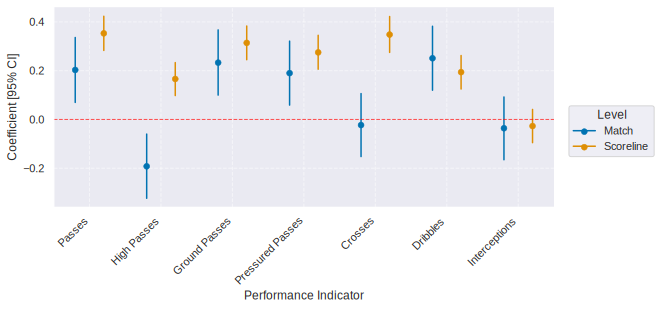

In [307]:
#| label: fig-coefficients-noseason
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 5
#| fig-height: 4
df_plot_noseason = df_plot[df_plot.level != 'season_level'].copy()

plot_coefficients(df_plot_noseason, full_palette)

### Demonstrate effect of scoreline on behavior

In [36]:
ls_indicators_plot

['passes',
 'highpasses',
 'groundpasses',
 'pressuredpasses',
 'crosses',
 'dribbles',
 'interceptions']

In [37]:
names_indicators_plot

['Passes',
 'High Passes',
 'Ground Passes',
 'Pressured Passes',
 'Crosses',
 'Dribbles',
 'Interceptions']

In [38]:
#| label: tbl-indicators-scoreline
#| tbl-cap: Means of Performance Indicators with Respect to Match Status

ls_dfs_context = []
for pi in ls_indicators_plot:
    df_scorelinelevel[pi + '_diff'] = df_scorelinelevel['home_' + pi] - df_scorelinelevel['away_' + pi]
    ls_dfs_context.append(df_scorelinelevel.groupby('match_status')[pi + '_diff'].mean().round(2))

df_context = pd.concat(ls_dfs_context, axis=1)
df_context.columns = df_context.columns.str.replace('_diff', '').map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_context.index.name = 'Match Status'
df_context.index = df_context.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    'home_leading': 'Home Leading'
})

df_context

,Passes,High Passes,Ground Passes,Pressured Passes,Crosses,Dribbles,Interceptions
Match Status,,,,,,,
Away Leading,16.59,1.97,11.40,0.27,1.61,-0.01,-0.34
Draw,14.21,0.67,12.65,-0.09,0.98,0.54,-0.21
Home Leading,-5.01,-0.53,-2.98,-0.40,-0.42,-0.16,0.31


### NEXT
-   choose 3 indicators (e.g. high passes, passes, pressures, )

In [39]:
df_scorelinelevel.groupby('match_status').agg(
    diff_highpasses = ('home_highpasses_90_scaled', lambda x: (x.mean() - df_scorelinelevel['away_highpasses_90_scaled'].mean()) / x.std()),
    diff_groundpasses = ('home_groundpasses_90_scaled', lambda x: (x.mean() - df_scorelinelevel['away_groundpasses_90_scaled'].mean()) / x.std()),
    diff_passes = ('home_passes_90_scaled', lambda x: (x.mean() - df_scorelinelevel['away_passes_90_scaled'].mean()) / x.std()),
    diff_xg = ('home_xg', lambda x: (x.mean() - df_scorelinelevel['away_xg'].mean()) / x.std())
)

,diff_highpasses,diff_groundpasses,diff_passes,diff_xg
match_status,,,,
away_leading,0.067310,0.129398,0.169956,-0.102868
draw,0.300112,0.290398,0.403142,0.112848
home_leading,-0.210132,0.044756,-0.013122,0.456611
